# Show Image Examples

Draw a few random YFCC4k images and run **all baseline attacks** against each one, then
save the clean and attacked images to `results/images_examples/`. These are the
qualitative examples used in the paper.

Baseline attacks covered (the same set as `evaluate-dataset`):

| Label | `run_attack` type | Notes |
|-------|-------------------|-------|
| `dtd` | `dtd` | Diffusion Trajectory Deviation (cosine-sim objective) |
| `encoder` | `encoder` | Encoder-space attack |
| `unidef` | `unidef` | UniDef / CDD global trajectory deviation |
| `ace` | `ace` | Targeted (pulls towards a target image) |
| `training_loss` | `training_loss` | Maximise the model's own training loss |
| `l2` | `diffusion_l2` | L2 trajectory deviation |
| `sampling` | `sampling` | Salman-style full-sampling attack |
| `geoshield` | *(out-of-process)* | Generated by the separate Geoshield repo |

Output layout (one folder per image):

```
results/images_examples/
  <image_id>/
    original.png          # full-resolution clean image
    clean.png             # model-preprocessed clean image (same space as attacks)
    dtd.png  encoder.png  unidef.png  ace.png  training_loss.png  l2.png  sampling.png
    geoshield.png
    comparison_grid.png   # side-by-side montage
  metadata.json
```


## Setup

In [1]:
import os
# Run from adversarial_demo/ (parent of demo_notebooks/). Idempotent.
if os.path.basename(os.getcwd()) == "demo_notebooks":
    os.chdir("..")
print("cwd:", os.getcwd())

cwd: /users/eleves-b/2023/mathias.ollu/repos/plonk/adversarial_demo


In [2]:
import json
import random
import shutil
import sys
from pathlib import Path

import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from attacks.attacks import run_attack
from utils.pipe_trajectory import PlonkPipelineTrajectory
from utils.adversarial_utils import (
    add_perturbation_to_image,
    conditional_preprocessing,
    tensor_to_pil,
    seed_everything,
    resolve_torch_device,
)
from utils.datasets import retrieve_yfcc_images

print("Imports OK")

/Data/mathias.ollu/conda/plonk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## Configuration

Pick how many random images to draw, the L-inf budget for the figure, and which attacks
to run. `SELECTION_SEED` controls which images are drawn (change it to resample);
`ATTACK_SEED` seeds the attack optimisation (matches the `seed` in `config.yaml`).

In [35]:
DATASET = "yfcc"
N_EXAMPLE_IMAGES = 3          # number of random images to draw
SELECTION_SEED = 137          # seed for drawing the random YFCC images (change to resample)
POOL_SIZE = 200               # draw the images from this many seeded YFCC samples
ATTACK_SEED = 42              # seed for the attack optimisation (matches config.yaml)
ATTACK_BUDGET = 8 / 255       # L-inf epsilon used for the qualitative figure (8/255)

# In-process baseline attacks: display label -> run_attack type.
ATTACKS = {
    "dtd": "dtd",
    "encoder": "encoder",
    "unidef": "unidef",
    "ace": "ace",
    "training_loss": "training_loss",
    "l2": "diffusion_l2",
    "sampling": "sampling",
}

RUN_GEOSHIELD = True          # also run the out-of-process GeoShield attack (Geoshield repo)

# Fast dry-run (lower fidelity, NOT for the paper figure): set True to sanity-check quickly.
FAST_MODE = False

# Paper-figure assets live under the repo's .media/ (one folder per image).
OUTPUT_DIR = Path("../.media/images_examples")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUTPUT_DIR.resolve())

Output dir: /users/eleves-b/2023/mathias.ollu/repos/plonk/.media/images_examples


Load `config.yaml` and build the shared attack kwargs exactly like
`main.get_attack_kwargs` does: the per-dataset `attack_train_args` block, minus the
`per_attack` overrides (e.g. ACE's target image / loss), which are applied per attack
type below. We only add the `eps_max` budget for this figure.

In [4]:
with open("config.yaml") as f:
    config = yaml.safe_load(f)

device = resolve_torch_device(config.get("device", "cuda"))

base_kwargs = dict(config["attack_train_args"][DATASET])
per_attack_overrides = base_kwargs.pop("per_attack", {}) or {}
base_kwargs["device"] = device
base_kwargs["eps_max"] = ATTACK_BUDGET
_rev = base_kwargs.get("restart_eval_seed")
base_kwargs["restart_eval_seed"] = ATTACK_SEED if _rev in (None, "seed") else int(_rev)

if FAST_MODE:
    base_kwargs.update(
        n_steps=20, num_restarts=1, restart_eval_num_steps=16,
        anchor_samples=128, restart_eval_batch_size=64,
    )

print("Device:", device)
print("Budget:", round(ATTACK_BUDGET * 255), "/255")
print("Base attack kwargs:", base_kwargs)
print("Per-attack overrides:", per_attack_overrides)

Device: cuda
Budget: 8 /255
Base attack kwargs: {'n_steps': 60, 'train_batch_size': 256, 'lr': 0.001, 'anchor_samples': 512, 'sampling_steps_salman': 16, 'clean_num_steps': 100, 'target_pure_noise': False, 'dot_product_loss': 'cosine_similarity_negative', 'reconstruction_loss_weight': 0.0, 'num_restarts': 5, 'restart_selection_metric': 'final_step_displacement', 'restart_eval_cfg': 10.0, 'restart_eval_batch_size': 128, 'restart_eval_seed': 42, 'restart_eval_num_steps': 250, 'device': 'cuda', 'eps_max': 0.03137254901960784}
Per-attack overrides: {'ace': {'dot_product_loss': 'l2_target', 'target_image': '/users/eleves-b/2023/mathias.ollu/repos/plonk/.media/MIST.png', 'alpha': 1}}


In [5]:
print("Loading pipeline:", config["pipelines"][DATASET])
pipeline = PlonkPipelineTrajectory(config["pipelines"][DATASET]).to(device)
print("Pipeline loaded")

Loading pipeline: nicolas-dufour/PLONK_YFCC


Using cache found in /users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main
/users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Pipeline loaded


## Draw random images

Loaded 200 images from YFCC4k (window [0:None] of pool 200).
Selected image ids: ['5314519767', '7769850426', '1959922547']


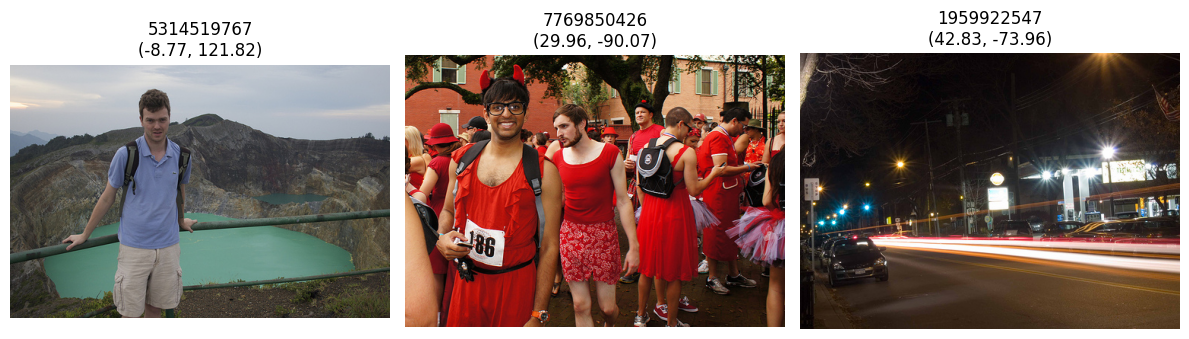

In [36]:
# Draw N_EXAMPLE_IMAGES random images from a seeded YFCC4k pool (reproducible).
pool_imgs, pool_gps, pool_ids = retrieve_yfcc_images(
    n_images_to_eval=POOL_SIZE, seed=SELECTION_SEED, local_dir=config["data_dirs"][DATASET],
)
_rng = random.Random(SELECTION_SEED)
_idx = _rng.sample(range(len(pool_imgs)), N_EXAMPLE_IMAGES)
example_images = [pool_imgs[i] for i in _idx]
example_gps = [pool_gps[i] for i in _idx]
example_ids = [pool_ids[i] for i in _idx]
print("Selected image ids:", example_ids)

fig, axes = plt.subplots(1, N_EXAMPLE_IMAGES, figsize=(4 * N_EXAMPLE_IMAGES, 4))
for ax, img, iid, gps in zip(np.atleast_1d(axes), example_images, example_ids, example_gps):
    ax.imshow(img)
    ax.set_title(f"{iid}\n({gps[0]:.2f}, {gps[1]:.2f})")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [14]:
def image_dir(image_id):
    d = OUTPUT_DIR / str(image_id)
    d.mkdir(parents=True, exist_ok=True)
    return d

# Save clean images: full-resolution original + model-preprocessed (same space as attacks).
for img, iid in zip(example_images, example_ids):
    d = image_dir(iid)
    img.save(d / "original.png")
    clean_tensor = conditional_preprocessing(img, pipeline, device=device)
    tensor_to_pil(clean_tensor).save(d / "clean.png")
print("Saved clean images.")

Saved clean images.


## Run the in-process baseline attacks

Each attack is trained per image with the shared config kwargs (plus its per-attack
overrides). The best perturbation `delta` is applied to the clean image and saved.

In [ ]:
records = []

def run_one_attack(attack_type, source_image):
    kwargs = dict(base_kwargs)
    kwargs.update(per_attack_overrides.get(attack_type, {}))
    seed_everything(ATTACK_SEED)
    result = run_attack(
        attack_type=attack_type,
        source_image=source_image,
        pipeline=pipeline,
        silent=True,
        **kwargs,
    )
    attacked = add_perturbation_to_image(source_image, result["delta"], pipeline)
    disp = (result.get("best_metrics") or {}).get("final_step_displacement")
    return attacked, disp

for img, iid in zip(example_images, example_ids):
    d = image_dir(iid)
    for label, atype in ATTACKS.items():
        print(f"[{iid}] running {label} ...", flush=True)
        attacked, disp = run_one_attack(atype, img)
        attacked.save(d / f"{label}.png")
        records.append({"image_id": iid, "attack": label, "final_step_displacement_km": disp})
        msg = f"   saved {label}.png"
        if disp is not None:
            msg += f"  (final-step displacement {disp:.1f} km)"
        print(msg, flush=True)

print("In-process attacks done.")

## GeoShield (out-of-process)

GeoShield is not a trainable attack in this repo: its perturbations are produced by the
separate **Geoshield** repo (`Geoshield/geoshield.py`). We copy the chosen images into a
clean dir, run the generator once at the matching epsilon (`round(budget * 255)`), and
copy the attacked images back. Wrapped in `try/except` so the notebook still completes if
the GeoShield environment is unavailable.

In [ ]:
if RUN_GEOSHIELD:
    from utils.geoshield import (
        _run_geoshield_generation,
        geoshield_epsilon_for_budget,
        default_repos_root,
    )

    gcfg = config.get("geoshield", {}) or {}
    repos_root = gcfg.get("repos_root") or str(default_repos_root())

    # Absolute paths: GeoShield runs from repos_root, so relative paths would resolve
    # against the wrong directory.
    gs_clean = (OUTPUT_DIR / "_geoshield_clean").resolve()
    gs_out = (OUTPUT_DIR / "_geoshield_out").resolve()
    if gs_clean.exists():
        shutil.rmtree(gs_clean)
    gs_clean.mkdir(parents=True)

    name_to_id = {}
    for img, iid in zip(example_images, example_ids):
        fname = f"{iid}.jpg"
        img.save(gs_clean / fname)
        name_to_id[fname] = iid

    epsilon = geoshield_epsilon_for_budget(ATTACK_BUDGET)
    try:
        attacked_dir = _run_geoshield_generation(
            repos_root=repos_root,
            script=gcfg.get("script", "Geoshield/geoshield.py"),
            python_exe=gcfg.get("python") or sys.executable,
            clean_dir=str(gs_clean),
            output_path=str(gs_out),
            n_images=len(name_to_id),
            epsilon=int(epsilon),
            steps=int(gcfg.get("steps", 100)),
        )
        for fname, iid in name_to_id.items():
            stem = Path(fname).stem
            cands = list(Path(attacked_dir).glob(stem + ".*"))
            if cands:
                Image.open(cands[0]).convert("RGB").save(image_dir(iid) / "geoshield.png")
                records.append({"image_id": iid, "attack": "geoshield",
                                "final_step_displacement_km": None})
                print(f"[{iid}] saved geoshield.png")
            else:
                print(f"[{iid}] WARNING: no GeoShield output found for {stem}")
    except Exception as exc:
        print("GeoShield generation failed (skipping):", exc)
else:
    print("RUN_GEOSHIELD is False; skipping GeoShield.")

## Comparison grids

In [ ]:
panel_order = ["clean"] + list(ATTACKS.keys()) + (["geoshield"] if RUN_GEOSHIELD else [])

for iid in example_ids:
    d = image_dir(iid)
    panels = [(name, d / f"{name}.png") for name in panel_order if (d / f"{name}.png").exists()]
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 2.8))
    for ax, (name, path) in zip(np.atleast_1d(axes), panels):
        ax.imshow(Image.open(path))
        ax.set_title(name, fontsize=9)
        ax.axis("off")
    fig.suptitle(f"Image {iid} -- budget {round(ATTACK_BUDGET * 255)}/255")
    plt.tight_layout()
    fig.savefig(d / "comparison_grid.png", dpi=150, bbox_inches="tight")
    plt.show()

## Map: predicted locations under attack

For each selected image we plot, on a world map, the **true GPS location**, the **clean
prediction**, and the **predicted location of every attack** (including **DTD**, this
paper's contribution). PLONK is generative, so each image yields a *distribution* of GPS
samples; we summarise each with its **geometric medoid** (the sample minimising total
great-circle distance to the rest — robust to multi-modal spreads and the date line).

Design choices for a publication-ready, easy-to-read figure:

- **True location** = gold star, **clean prediction** = white circle, **DTD (ours)** = bold
  red star, every other attack a distinct colour/marker (see legend).
- Faint great-circle **connectors** run from the clean prediction to each attack, so the
  displacement each attack induces is visible at a glance (DTD's is drawn thicker).
- A **zoom inset** frames the region around the true location. Attacks that fail to move
  the prediction land *on top of* the clean prediction; in the inset these coincident
  markers are **exploded onto a small ring** (with thin grey leader lines) so each stays
  individually visible.

Predictions are cached to `prediction_points.json` per image, so you can restyle the map
without re-running the pipeline (set `RECOMPUTE_PREDICTIONS = True` to force a refresh).

In [11]:
import matplotlib.lines as mlines
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.adversarial_utils import make_shared_initial_noise

# --- map sampling settings ---
MAP_NUM_STEPS = 250           # sampling steps for the predicted-GPS distribution
MAP_N_SAMPLES = 256           # number of GPS samples drawn per image
MAP_SEED = 1234               # shared initial noise / seed (clean & attacks comparable)
RECOMPUTE_PREDICTIONS = False  # True => ignore cached prediction_points.json and re-sample
GLOBAL_FAN_SPAN = 9.0         # degrees; explode coincident attack clusters on the world map

# attack label -> (colour, marker, size, legend name). DTD is highlighted.
ATTACK_STYLE = {
    "dtd":           ("#e6194B", "*", 430, "DTD (ours)"),
    "encoder":       ("#4363d8", "s", 90,  "Encoder"),
    "unidef":        ("#3cb44b", "^", 95,  "UniDef"),
    "ace":           ("#911eb4", "v", 95,  "ACE"),
    "training_loss": ("#f58231", "P", 100, "Training loss"),
    "l2":            ("#42d4f4", "X", 95,  "L2"),
    "sampling":      ("#808080", "h", 95,  "Sampling"),
    "geoshield":     ("#bfef45", "p", 100, "GeoShield"),
}
ATTACK_ORDER = list(ATTACK_STYLE.keys())


def haversine_km(a, b):
    """Great-circle distance (km) from point a=(lat,lon) to each row of b=[N,2] (lat,lon)."""
    R = 6371.0
    b = np.atleast_2d(b)
    lat1, lon1, lat2, lon2 = map(np.radians, [a[0], a[1], b[:, 0], b[:, 1]])
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(h))


def medoid(gps):
    """gps: [N,2] (lat,lon). Returns the sample minimising total haversine to the rest."""
    best, best_cost = 0, np.inf
    for i in range(len(gps)):
        c = float(haversine_km((gps[i, 0], gps[i, 1]), gps).sum())
        if c < best_cost:
            best_cost, best = c, i
    return gps[best]


@torch.inference_mode()
def predict_gps(image):
    """Sample MAP_N_SAMPLES predicted GPS points for a PIL image (shared noise + seed)."""
    import random
    x_n = make_shared_initial_noise(MAP_N_SAMPLES, device=device, seed=MAP_SEED)
    random.seed(MAP_SEED); np.random.seed(MAP_SEED); torch.manual_seed(MAP_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MAP_SEED)
    gps, _ = pipeline(image, batch_size=MAP_N_SAMPLES, cfg=10.0, x_N=x_n,
                      return_trajectories=True, num_steps=MAP_NUM_STEPS)
    return gps.detach().cpu().numpy() if torch.is_tensor(gps) else np.asarray(gps)


def _clusters(coords, thresh_km):
    """Connected components of points closer than thresh_km (union-find)."""
    n = len(coords)
    parent = list(range(n))
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    for i in range(n):
        for j in range(i + 1, n):
            if haversine_km(tuple(coords[i]), coords[j])[0] < thresh_km:
                parent[find(i)] = find(j)
    groups = {}
    for i in range(n):
        groups.setdefault(find(i), []).append(i)
    return list(groups.values())


def fan_layout(preds, clean_pred, span_deg, explode_clean=True):
    """Explode markers on (nearly) the same spot onto a small ring so each stays visible.

    Returns {label: (disp_lat, disp_lon, anchor_or_None)}; anchor is the real shared
    location a grey leader line is drawn back to (None when the marker was not moved).
    With explode_clean=False, clusters sitting on the clean prediction are left stacked
    (the zoom inset reveals those) so the global map's origin stays uncluttered."""
    labels = list(preds.keys())
    coords = [np.asarray(preds[l], dtype=float) for l in labels]
    thresh = max(150.0, span_deg * 35)
    r = span_deg * 0.16
    layout = {}
    for grp in _clusters(coords, thresh):
        cen = np.mean([coords[i] for i in grp], axis=0)
        near_clean = haversine_km(tuple(clean_pred), cen)[0] < thresh
        if len(grp) == 1 or (near_clean and not explode_clean):
            for i in grp:
                layout[labels[i]] = (coords[i][0], coords[i][1], None)
            continue
        anchor = np.asarray(clean_pred, dtype=float) if near_clean else cen
        for k, i in enumerate(grp):
            ang = 2 * np.pi * k / len(grp) + np.pi / 2
            dlat = anchor[0] + r * np.sin(ang)
            dlon = anchor[1] + r * np.cos(ang) / max(0.3, np.cos(np.radians(anchor[0])))
            layout[labels[i]] = (dlat, dlon, (anchor[0], anchor[1]))
    return layout


def _style_map(ax, labels=True):
    ax.add_feature(cfeature.OCEAN, facecolor="#eaf1f7")
    ax.add_feature(cfeature.LAND, facecolor="#ededed", edgecolor="none")
    ax.add_feature(cfeature.COASTLINE, edgecolor="#888888", linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="#aaaaaa", linewidth=0.4)
    gl = ax.gridlines(draw_labels=labels, linewidth=0.3, color="#bbbbbb", alpha=0.5, linestyle="--")
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {"size": 7}; gl.ylabel_style = {"size": 7}


def _draw_points(ax, true_gps, clean_pred, preds, with_connectors=True, fan_span=None,
                 explode_clean=True):
    """Draw connectors + markers. With fan_span (deg) coincident markers are exploded."""
    layout = (fan_layout(preds, clean_pred, fan_span, explode_clean) if fan_span
              else {l: (preds[l][0], preds[l][1], None) for l in preds})
    if with_connectors:
        for label, pt in preds.items():
            ax.plot([clean_pred[1], pt[1]], [clean_pred[0], pt[0]], transform=ccrs.Geodetic(),
                    color=ATTACK_STYLE[label][0], linewidth=2.2 if label == "dtd" else 0.9,
                    alpha=0.55, zorder=3)
    for label, (dlat, dlon, anchor) in layout.items():
        if anchor is not None:  # leader line for an exploded marker
            ax.plot([anchor[1], dlon], [anchor[0], dlat], transform=ccrs.PlateCarree(),
                    color="#555555", linewidth=0.7, alpha=0.8, zorder=6)
    for label in ATTACK_ORDER:
        if label not in layout:
            continue
        dlat, dlon, _ = layout[label]
        color, marker, size, _ = ATTACK_STYLE[label]
        ax.scatter(dlon, dlat, color=color, marker=marker, s=size,
                   edgecolors="black" if label == "dtd" else "white",
                   linewidths=1.6 if label == "dtd" else 0.7,
                   zorder=11 if label == "dtd" else 8, transform=ccrs.PlateCarree())
    ax.scatter(clean_pred[1], clean_pred[0], facecolor="white", marker="o", s=150,
               edgecolors="black", linewidths=1.3, zorder=9, transform=ccrs.PlateCarree())
    ax.scatter(true_gps[1], true_gps[0], color="#ffd700", marker="*", s=520,
               edgecolors="black", linewidths=1.4, zorder=12, transform=ccrs.PlateCarree())


def legend_handles(preds):
    h = [mlines.Line2D([], [], color="#ffd700", marker="*", linestyle="None",
                       markersize=18, markeredgecolor="black", label="True location"),
         mlines.Line2D([], [], color="white", marker="o", linestyle="None",
                       markersize=10, markeredgecolor="black", label="Clean prediction")]
    for label in ATTACK_ORDER:
        if label not in preds:
            continue
        color, marker, _, name = ATTACK_STYLE[label]
        h.append(mlines.Line2D([], [], color=color, marker=marker, linestyle="None",
                               markersize=11 if label == "dtd" else 8,
                               markeredgecolor="black" if label == "dtd" else "white", label=name))
    return h


def perturbation_views(clean_img, attacked_img, pct=99.5):
    """Two complementary renderings of the DTD perturbation delta = attacked - clean:

    - signed: delta centred at mid-grey and amplified (gain from a high percentile of
      |delta|, so outliers don't saturate it) so the additive perturbation is visible;
    - heatmap: per-pixel L2 magnitude |delta| on a perceptual colourmap, which reveals
      *where* the attack concentrates its perturbation (typically edges / salient content).
    Returns (signed_uint8, heatmap_uint8, gain)."""
    c = np.asarray(clean_img.convert("RGB"), dtype=float)
    a = np.asarray(attacked_img.convert("RGB"), dtype=float)
    diff = a - c
    scale = max(1.0, float(np.percentile(np.abs(diff), pct)))
    gain = 127.5 / scale
    signed = np.clip(127.5 + diff * gain, 0, 255).astype("uint8")
    mag = np.sqrt((diff ** 2).sum(axis=2))
    mag /= max(float(mag.max()), 1e-6)
    heatmap = (cm.inferno(mag)[:, :, :3] * 255).astype("uint8")
    return signed, heatmap, gain


def add_dtd_panels(fig, d, x0=0.36, y0=0.075, w=0.066, gap=0.005):
    """Compact clean / signed-delta / |delta|-heatmap / attacked panels, overlaid on the
    map's empty Southern-Ocean band so the figure stays map-width. Returns the gain (or
    None if the DTD images are missing)."""
    if not ((d / "clean.png").exists() and (d / "dtd.png").exists()):
        return None
    clean_img = Image.open(d / "clean.png").convert("RGB")
    attacked_img = Image.open(d / "dtd.png").convert("RGB")
    signed, heatmap, gain = perturbation_views(clean_img, attacked_img)
    h = w * (fig.get_figwidth() / fig.get_figheight())  # keep panels square
    panels = [(clean_img, "clean $x$"),
              (signed, f"DTD $\\delta$ (×{gain:.0f})"),
              (heatmap, "$|\\delta|$ (where)"),
              (attacked_img, "attacked $x{+}\\delta$")]
    fig.text(x0 + (2 * w + 1.5 * gap), y0 + h + 0.035, "DTD attack (this paper)",
             ha="center", va="bottom", fontsize=9, weight="bold")
    for i, (im, cap) in enumerate(panels):
        axi = fig.add_axes([x0 + i * (w + gap), y0, w, h])
        axi.imshow(im)
        axi.set_xticks([]); axi.set_yticks([])
        axi.set_title(cap, fontsize=7.5, pad=2)
        for s in axi.spines.values():
            s.set_edgecolor("#444444"); s.set_linewidth(0.8)
    return gain

print("Map helpers defined.")

Map helpers defined.


In [38]:
# Compute (or load cached) predicted locations for the clean image and every attack.
example_gps_by_id = {iid: tuple(g) for iid, g in zip(example_ids, example_gps)}
predictions = {}  # image_id -> {"true":(lat,lon), "clean":[lat,lon], "attacks":{label:[lat,lon]}}

for iid in example_ids:
    d = image_dir(iid)
    cache = d / "prediction_points.json"
    if cache.exists() and not RECOMPUTE_PREDICTIONS:
        predictions[iid] = json.load(open(cache))
        print(f"[{iid}] loaded cached predictions")
        continue
    if not (d / "clean.png").exists():
        print(f"[{iid}] no clean.png; run the attack cells first. Skipping.")
        continue
    clean_pred = medoid(predict_gps(Image.open(d / "clean.png").convert("RGB")))
    attacks = {}
    for label in ATTACK_ORDER:
        p = d / f"{label}.png"
        if p.exists():
            attacks[label] = [float(x) for x in medoid(predict_gps(Image.open(p).convert("RGB")))]
    rec = {"true": list(example_gps_by_id[iid]),
           "clean": [float(x) for x in clean_pred], "attacks": attacks}
    json.dump(rec, open(cache, "w"), indent=2)
    predictions[iid] = rec
    print(f"[{iid}] computed predictions for {len(attacks)} attacks")

[5314519767] loaded cached predictions
[7769850426] loaded cached predictions
[1959922547] loaded cached predictions


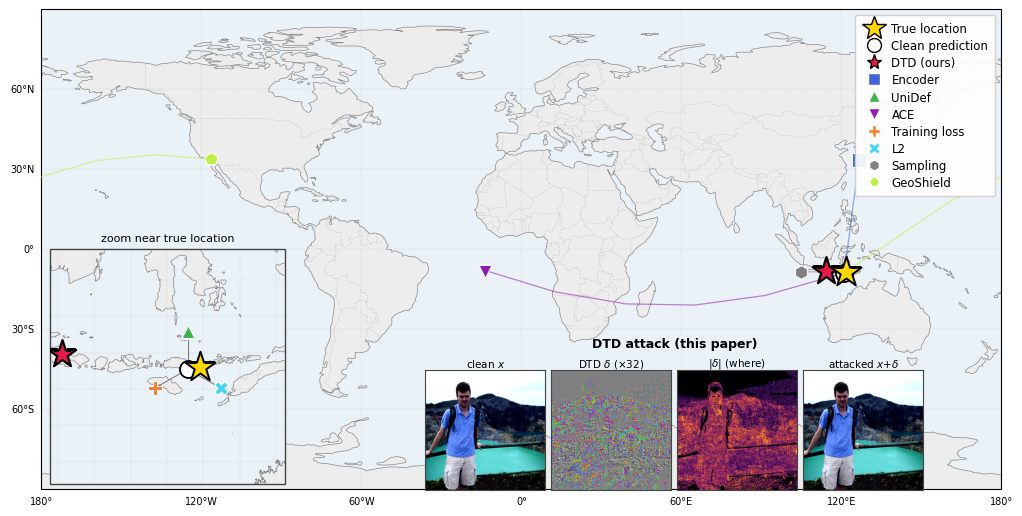

saved ../.media/images_examples/5314519767/prediction_map.png


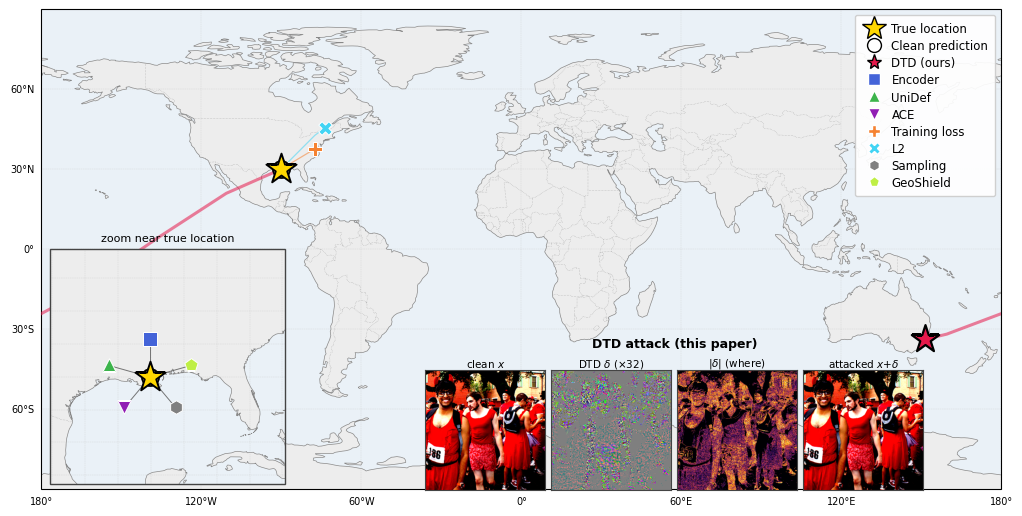

saved ../.media/images_examples/7769850426/prediction_map.png


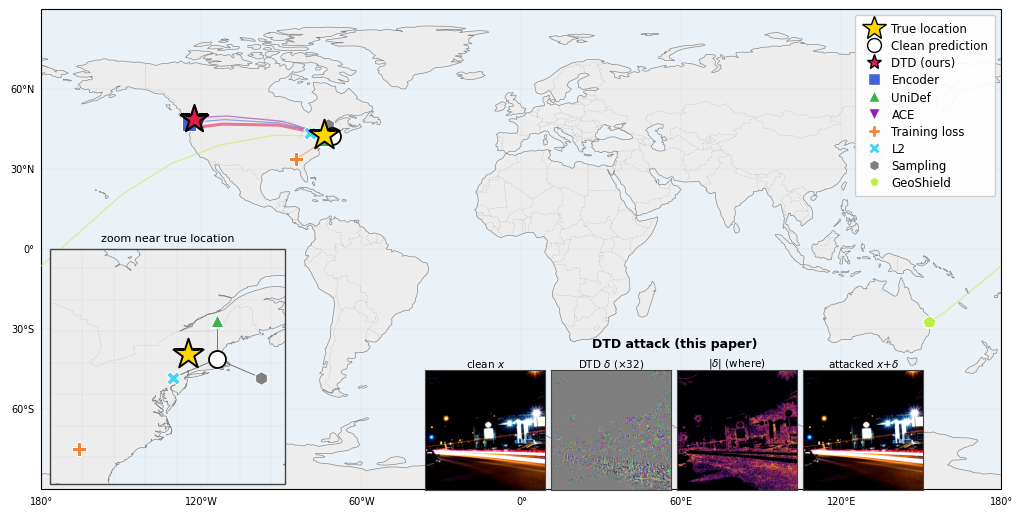

saved ../.media/images_examples/1959922547/prediction_map.png


In [41]:
# Draw one publication-ready map per image (global view + exploded zoom inset).
for iid in example_ids:
    if iid not in predictions:
        continue
    d = image_dir(iid)
    rec = predictions[iid]
    true_gps = tuple(rec["true"])
    clean_pred = np.asarray(rec["clean"], dtype=float)
    preds = {l: np.asarray(p, dtype=float) for l, p in rec["attacks"].items()}

    fig = plt.figure(figsize=(12, 5.6))
    ax = fig.add_axes([0.025, 0.04, 0.80, 0.93], projection=ccrs.PlateCarree())
    ax.set_global()
    _style_map(ax)
    _draw_points(ax, true_gps, clean_pred, preds, fan_span=GLOBAL_FAN_SPAN, explode_clean=False)

    # zoom inset framing the true/clean cluster (large, lower-left)
    near = [true_gps, tuple(clean_pred)] + [
        tuple(p) for p in preds.values() if haversine_km(tuple(clean_pred), p)[0] < 1500
    ]
    near = np.array(near)
    lat_c, lon_c = float(near[:, 0].mean()), float(near[:, 1].mean())
    span = max(7.0, float(np.ptp(near[:, 0])) * 1.7, float(np.ptp(near[:, 1])) * 1.7)
    ext = [lon_c - span / 2, lon_c + span / 2, lat_c - span / 2, lat_c + span / 2]
    axins = fig.add_axes([0.0, 0.085, 0.26, 0.42], projection=ccrs.PlateCarree())
    axins.set_extent(ext, crs=ccrs.PlateCarree())
    _style_map(axins, labels=False)
    preds_in = {l: p for l, p in preds.items()
                if ext[0] <= p[1] <= ext[1] and ext[2] <= p[0] <= ext[3]}
    _draw_points(axins, true_gps, clean_pred, preds_in, with_connectors=False, fan_span=span)
    for s in axins.spines.values():
        s.set_edgecolor("#444444"); s.set_linewidth(1.0)
    axins.set_title("zoom near true location", fontsize=8)

    # DTD perturbation panels overlaid on the map's (empty) Southern-Ocean band, so the
    # figure stays map-width rather than growing a side column.
    add_dtd_panels(fig, d, x0=0.345, y0=0.075, w=0.1)
    if "dtd" in preds:
        dtd_km = float(haversine_km(tuple(clean_pred), preds["dtd"])[0])
        # fig.text(0.715, 0.14, f"DTD shifts the prediction\nby {dtd_km:,.0f} km",
        #          ha="center", va="center", fontsize=9, color="#7a0a22",
        #          bbox=dict(boxstyle="round,pad=0.35", fc="#fdeef1", ec="#e6194B", lw=1.0))

    # legend overlaid inside the map's top-right corner (semi-transparent so markers behind
    # it stay readable). No external margin => bbox_inches="tight" trims the figure to the map.
    leg = ax.legend(handles=legend_handles(preds), loc="upper right",
                    fontsize=8.5, frameon=True, framealpha=0.92, facecolor="white",
                    edgecolor="#cccccc", borderpad=0.6, labelspacing=0.35, handletextpad=0.5)
    leg.set_zorder(20)

    fig.savefig(d / "prediction_map.png", dpi=200, bbox_inches="tight")
    #also save in max quality for paper:
    fig.savefig(d / "prediction_map_max.pdf", dpi=1200,    bbox_inches="tight",)
    plt.show()
    print("saved", d / "prediction_map.png")

## Save metadata

In [ ]:
metadata = {
    "dataset": DATASET,
    "budget_over_255": round(ATTACK_BUDGET * 255),
    "selection_seed": SELECTION_SEED,
    "attack_seed": ATTACK_SEED,
    "fast_mode": FAST_MODE,
    "image_ids": example_ids,
    "image_gps": {iid: list(gps) for iid, gps in zip(example_ids, example_gps)},
    "attacks": list(ATTACKS.keys()) + (["geoshield"] if RUN_GEOSHIELD else []),
    "records": records,
}
with open(OUTPUT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Wrote", (OUTPUT_DIR / "metadata.json").resolve())
print("Example folders:")
for iid in example_ids:
    print("  ", image_dir(iid).resolve())

## TikZ teaser figure (paper hero figure)

A standalone, hand-editable pgfplots twin of the map above, built specifically for the
paper's teaser: instead of every attack, it pins just the **source photo** (at its true
location) alongside the **DTD (ours)** and **GeoShield** attacked photos (at their
predicted locations), connected by great-circle lines back to the clean prediction --
same story as the map above, fewer attacks, real image thumbnails as TikZ nodes.

Reads the same cached `prediction_points.json` (no re-running the pipeline). Outputs
land in `<image_dir>/tikz/teaser_<image_id>.{tex,pdf,png}` (+ copies of the three PNGs
and the background world map next to the `.tex`, so that folder is self-contained and
portable). The `.pdf`/`.png` are a best-effort local compile (via pdflatex, falling back
to lualatex for large data) so you can preview it here; the `.tex` itself will compile
anywhere pgfplots is available (e.g. Overleaf) and every marker/line/label is a normal
TikZ node you can nudge by hand -- e.g. if the legend or a thumbnail happens to land
somewhere awkward for a specific image.

Pick whichever `example_ids` entry tells the best story for the teaser (biggest
DTD/GeoShield displacement, clearest map layout, etc.) -- there's one figure per image.

In [ ]:
from utils.plots_tikz import plot_geolocation_teaser_tikz

teaser_results = {}
for iid in example_ids:
    d = image_dir(iid)
    if not (d / "prediction_points.json").exists():
        print(f"[{iid}] no prediction_points.json; run the map cells above first. Skipping.")
        continue
    teaser_results[iid] = plot_geolocation_teaser_tikz(image_dir=d, attack_labels=("dtd", "geoshield"))

print("\nDone. Preview PNGs (if pdflatex/lualatex are available):")
for iid, r in teaser_results.items():
    print(f"  {iid}: {r.get('png') or r['tex']}")